<a href="https://colab.research.google.com/github/uide-programacion-inteligencia-mercados/observatorio-g02/blob/main/C06_LABORATORIO_ORQUESTACION_AnthonyLandeta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio · Semana 6 · El director de orquesta de tus datos
**Programación Aplicada a la Inteligencia de Mercados · UIDE Business School · Juan Carlos Correa / Docente**

Hasta ahora, cada robot de tu observatorio trabajaba cuando tú le pulsabas el botón. Hoy aprendes a ponerlos a trabajar **solos, en orden y todos los días**, sin que nadie esté sentado frente a la pantalla.

### Qué vas a hacer
1. Ver la receta del día: qué tarea espera a cuál.
2. Ejecutarla y ver qué puede hacerse a la vez.
3. Probar qué pasa cuando una fuente no contesta.
4. Elegir el reloj: a qué hora trabaja tu robot.
5. Leer un archivo de trabajo real de GitHub.
6. Armar el paquete de tu equipo y subirlo a su casa.

### El botón que vas a usar
Cada paso tiene **una celda gris con un título**. A la izquierda del título está el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> (un círculo con un triángulo). **Pulsarlo hace el paso.** Si hay recuadros, primero escribes y después pulsas.

⏱️ Tiempo total: unos 60 minutos. Todo ocurre en el navegador: no instalas nada.

## PASO 0 · Ponerle tu nombre a tu cuaderno

**🔗 Lo que ya tienes:** este cuaderno abierto en Colab (lo bajaste de Canvas y lo subiste con el botón *Subir notebook*).

**🎯 En este paso:** le pones el nombre de tu equipo, para encontrarlo después.

**👆 Qué haces:** haz clic en el nombre del cuaderno (arriba a la izquierda), bórralo, escribe **`C06_Laboratorio_Equipo_G0X`** (cambia la X por el número de tu equipo) y pulsa **Enter**.

**👀 Qué debes ver:** arriba a la izquierda, el nuevo nombre.

**🧩 Lo que te llevas al paso siguiente:** un cuaderno con nombre propio.

## PASO 1 · La receta del día

**🔗 Lo que ya tienes:** nada todavía: es el primer paso real.

**🎯 En este paso:** ves, dibujadas, las seis tareas del observatorio de referencia del profesor y de cuál depende cada una. A esa receta se le llama **DAG** (se lee «dag»): un conjunto de tareas con un orden, sin vueltas hacia atrás.

**👆 Qué haces:** pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo. No escribes nada.

**👀 Qué debes ver:** una tabla con las seis tareas y un dibujo de cajas. Al final: `✅ Paso 1 listo`.

**🧩 Lo que te llevas al paso siguiente:** la receta cargada en el cuaderno.

,tarea,etapa,espera a,qué hace
0,remax,BUSCAR,nadie (puede arrancar ya),Trae los anuncios de venta de RE/MAX
1,banco_mundial,BUSCAR,nadie (puede arrancar ya),"Trae inflación, PIB y crédito"
2,fmi,BUSCAR,nadie (puede arrancar ya),Trae el crecimiento según el FMI
3,limpiar,LIMPIAR,"remax, banco_mundial, fmi",Quita repetidos y datos imposibles
4,analizar,ANALIZAR,limpiar,Calcula precio por m² y la alerta
5,reportar,MOSTRAR,analizar,Arma el gráfico y el reporte


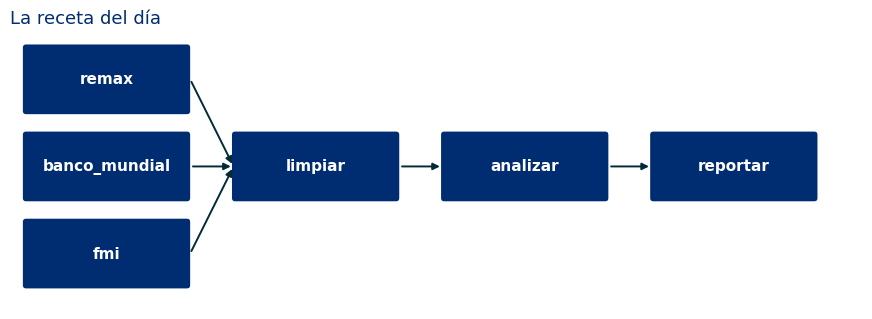

Lectura: las tres tareas de la izquierda no se esperan entre sí. 'limpiar' espera a las tres.
✅ Paso 1 listo


In [1]:
#@title PASO 1 · La receta del día { display-mode: "form" }
#@markdown Pulsa el botón redondo (no escribes nada)
import time, json, math
from datetime import datetime, timedelta, timezone
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import pandas as pd

AZUL, MAGENTA, ORO, GRIS, PROF = "#002C71", "#910048", "#EAAA00", "#E7E6E6", "#002C38"

# La receta: cada tarea dice de cuáles depende y cuánto tarda (en segundos de ejemplo).
RECETA = {
    "remax":         {"depende_de": [],                                   "tarda": 4, "etapa": "BUSCAR",   "que_hace": "Trae los anuncios de venta de RE/MAX"},
    "banco_mundial": {"depende_de": [],                                   "tarda": 2, "etapa": "BUSCAR",   "que_hace": "Trae inflación, PIB y crédito"},
    "fmi":           {"depende_de": [],                                   "tarda": 1, "etapa": "BUSCAR",   "que_hace": "Trae el crecimiento según el FMI"},
    "limpiar":       {"depende_de": ["remax", "banco_mundial", "fmi"],    "tarda": 2, "etapa": "LIMPIAR",  "que_hace": "Quita repetidos y datos imposibles"},
    "analizar":      {"depende_de": ["limpiar"],                          "tarda": 1, "etapa": "ANALIZAR", "que_hace": "Calcula precio por m² y la alerta"},
    "reportar":      {"depende_de": ["analizar"],                         "tarda": 1, "etapa": "MOSTRAR",  "que_hace": "Arma el gráfico y el reporte"},
}

def orden_valido(receta):
    hechas, pendientes = [], dict(receta)
    while pendientes:
        salen = [n for n, t in pendientes.items() if all(d in hechas for d in t["depende_de"])]
        if not salen:
            raise ValueError("Hay un ciclo: dos tareas se esperan entre sí.")
        for n in sorted(salen):
            hechas.append(n); del pendientes[n]
    return hechas

def dibujar_receta(receta, resaltar=None, titulo="La receta del día"):
    cols = {"remax": (0, 2), "banco_mundial": (0, 1), "fmi": (0, 0), "limpiar": (1, 1), "analizar": (2, 1), "reportar": (3, 1)}
    fig, ax = plt.subplots(figsize=(11, 3.6))
    for n, (x, y) in cols.items():
        if n not in receta: continue
        color = (resaltar or {}).get(n, AZUL)
        ax.add_patch(FancyBboxPatch((x * 2.6, y * 1.1), 2.0, 0.8, boxstyle="round,pad=0.04", fc=color, ec="none"))
        ax.text(x * 2.6 + 1.0, y * 1.1 + 0.4, n, ha="center", va="center", color="white", fontsize=11, fontweight="bold")
        for d in receta[n]["depende_de"]:
            dx, dy = cols[d]
            ax.annotate("", xy=(x * 2.6 - 0.02, y * 1.1 + 0.4), xytext=(dx * 2.6 + 2.04, dy * 1.1 + 0.4),
                        arrowprops=dict(arrowstyle="-|>", color=PROF, lw=1.4))
    ax.set_xlim(-0.2, 10.4); ax.set_ylim(-0.3, 3.2); ax.axis("off"); ax.set_title(titulo, color=AZUL, fontsize=13, loc="left")
    plt.show()

tabla = pd.DataFrame([{"tarea": n, "etapa": t["etapa"], "espera a": ", ".join(t["depende_de"]) or "nadie (puede arrancar ya)", "qué hace": t["que_hace"]}
                      for n, t in RECETA.items()])
display(tabla)
dibujar_receta(RECETA)
print("Lectura: las tres tareas de la izquierda no se esperan entre sí. 'limpiar' espera a las tres.")
print("✅ Paso 1 listo")

## PASO 2 · Ejecutar en orden y ver qué puede ir a la vez

**🔗 Lo que ya tienes:** la receta del día (Paso 1).

**🎯 En este paso:** comparas dos maneras de ejecutar la misma receta: una tarea tras otra, o varias a la vez cuando no se esperan entre sí.

**👆 Qué haces:** pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo. No escribes nada.

**👀 Qué debes ver:** el orden en que se ejecutan las tareas y dos barras de tiempo. Al final: `✅ Paso 2 listo`.

**🧩 Lo que te llevas al paso siguiente:** la idea de que un orquestador ahorra tiempo sin romper el orden.

Orden en que el director ejecuta las tareas:
  1. banco_mundial
  2. fmi
  3. remax
  4. limpiar
  5. analizar
  6. reportar


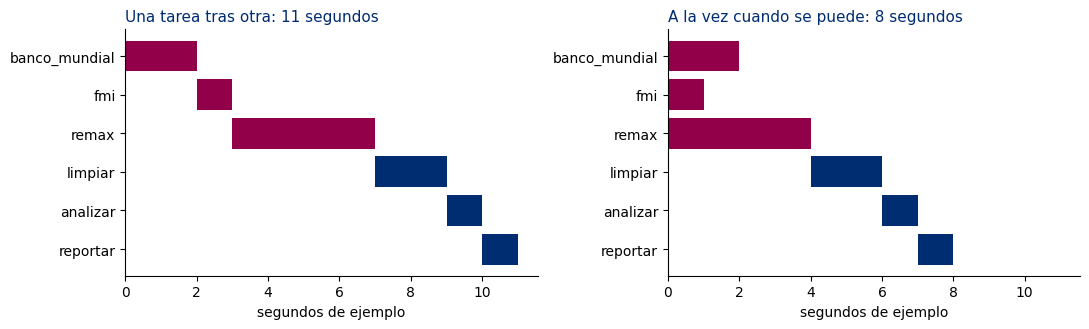

Una tras otra: 11 s. A la vez cuando se puede: 8 s. Ahorro: 3 s.
Las tres barras magenta son las fuentes: no se esperan entre sí, por eso pueden ir juntas.
✅ Paso 2 listo


In [2]:
#@title PASO 2 · Ejecutar en orden { display-mode: "form" }
#@markdown Pulsa el botón redondo (no escribes nada)
if "RECETA" not in globals():
    print("✋ Todavía no puedes hacer este paso: primero pulsa el botón redondo del Paso 1.")
else:
    orden = orden_valido(RECETA)
    print("Orden en que el director ejecuta las tareas:")
    for i, n in enumerate(orden, 1):
        print(f"  {i}. {n}")

    # Una tras otra
    t, seguido = 0, {}
    for n in orden:
        seguido[n] = (t, t + RECETA[n]["tarda"]); t += RECETA[n]["tarda"]
    total_seguido = t
    # A la vez cuando se puede
    paralelo = {}
    for n in orden:
        ini = max([paralelo[d][1] for d in RECETA[n]["depende_de"]], default=0)
        paralelo[n] = (ini, ini + RECETA[n]["tarda"])
    total_paralelo = max(f for _, f in paralelo.values())

    fig, ejes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True)
    for ax, datos, nombre, tot in [(ejes[0], seguido, "Una tarea tras otra", total_seguido), (ejes[1], paralelo, "A la vez cuando se puede", total_paralelo)]:
        for i, n in enumerate(orden):
            ini, fin = datos[n]
            ax.barh(i, fin - ini, left=ini, color=MAGENTA if n in ("remax", "banco_mundial", "fmi") else AZUL)
        ax.set_yticks(range(len(orden))); ax.set_yticklabels(orden); ax.invert_yaxis()
        ax.set_title(f"{nombre}: {tot} segundos", color=AZUL, fontsize=11, loc="left"); ax.set_xlabel("segundos de ejemplo")
        for lado in ("top", "right"): ax.spines[lado].set_visible(False)
    plt.tight_layout(); plt.show()
    print(f"Una tras otra: {total_seguido} s. A la vez cuando se puede: {total_paralelo} s. Ahorro: {total_seguido - total_paralelo} s.")
    print("Las tres barras magenta son las fuentes: no se esperan entre sí, por eso pueden ir juntas.")
    print("✅ Paso 2 listo")

## PASO 3 · ¿Y si una fuente no contesta?

**🔗 Lo que ya tienes:** el orden de ejecución (Paso 2).

**🎯 En este paso:** pruebas qué hace el director cuando una tarea no logra terminar: reintenta, usa el plan B o se detiene.

**👆 Qué haces:** 1. En el recuadro **FUENTE_QUE_NO_CONTESTA** elige qué tarea imaginas que se cae.
2. En **REINTENTOS** elige cuántas veces más debe intentarlo el director.
3. Marca o desmarca **TIENE_PLAN_B** (si la fuente tiene un archivo de respaldo).
4. Pulsa <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">. Puedes cambiar los recuadros y volver a pulsar las veces que quieras.

**👀 Qué debes ver:** una línea por cada tarea con su resultado: ✅ bien, 🔁 bien con plan B, ❌ falló, ⏭️ omitida. Al final: `✅ Paso 3 listo`.

**🧩 Lo que te llevas al paso siguiente:** la regla de oro: **una tarea que depende de otra caída no se ejecuta**. Por eso cada fuente necesita su plan B.

Imaginamos que 'banco_mundial' no contesta. Reintentos permitidos: 2. Plan B: sí.

     banco_mundial: intento 1 sin respuesta
     banco_mundial: intento 2 sin respuesta
     banco_mundial: intento 3 sin respuesta
  🔁 banco_mundial: bien, con el archivo de respaldo (plan B)
  ✅ fmi: bien
  ✅ remax: bien
  ✅ limpiar: bien
  ✅ analizar: bien
  ✅ reportar: bien


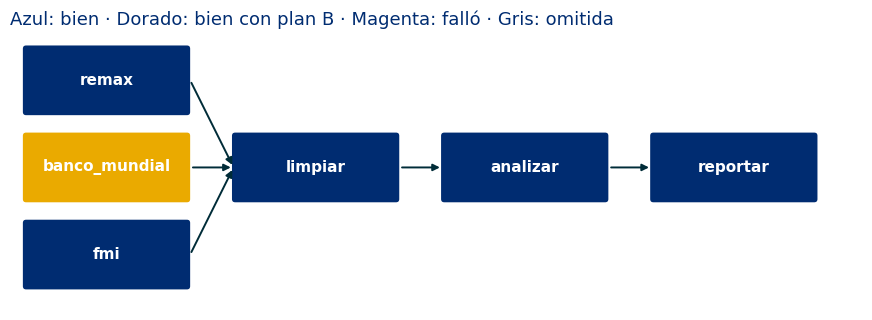

Resultado: la caída no detuvo al observatorio. Ese es el trabajo del plan B.
✅ Paso 3 listo


In [4]:
#@title PASO 3 · Cuando una fuente no contesta { display-mode: "form" }
FUENTE_QUE_NO_CONTESTA = "banco_mundial" #@param ["ninguna", "remax", "banco_mundial", "fmi", "limpiar"]
REINTENTOS = 2 #@param {type:"slider", min:0, max:3, step:1}
TIENE_PLAN_B = True #@param {type:"boolean"}
#@markdown Pulsa el botón redondo
if "RECETA" not in globals():
    print("✋ Todavía no puedes hacer este paso: primero pulsa el botón redondo del Paso 1.")
else:
    estado, colores = {}, {}
    fuentes = ("remax", "banco_mundial", "fmi")
    print(f"Imaginamos que '{FUENTE_QUE_NO_CONTESTA}' no contesta. Reintentos permitidos: {REINTENTOS}. Plan B: {'sí' if TIENE_PLAN_B else 'no'}.\n")
    for n in orden_valido(RECETA):
        if any(estado.get(d) in ("fallo", "omitida") for d in RECETA[n]["depende_de"]):
            estado[n] = "omitida"; colores[n] = "#8A8A8A"
            print(f"  ⏭️  {n}: omitida (dependía de una tarea que falló)")
            continue
        if n != FUENTE_QUE_NO_CONTESTA:
            estado[n] = "ok"; colores[n] = AZUL
            print(f"  ✅ {n}: bien")
            continue
        for intento in range(1, REINTENTOS + 2):
            print(f"     {n}: intento {intento} sin respuesta")
        if TIENE_PLAN_B and n in fuentes:
            estado[n] = "ok"; colores[n] = ORO
            print(f"  🔁 {n}: bien, con el archivo de respaldo (plan B)")
        else:
            estado[n] = "fallo"; colores[n] = MAGENTA
            print(f"  ❌ {n}: falló")
    dibujar_receta(RECETA, resaltar=colores, titulo="Azul: bien · Dorado: bien con plan B · Magenta: falló · Gris: omitida")
    omitidas = [n for n, e in estado.items() if e == "omitida"]
    if FUENTE_QUE_NO_CONTESTA == "ninguna":
        print("Todo funcionó. Cambia el primer recuadro para ver qué pasa si algo se cae.")
    elif omitidas:
        print(f"Resultado: se perdieron {len(omitidas)} tareas por una sola caída. Marca TIENE_PLAN_B y vuelve a pulsar.")
    else:
        print("Resultado: la caída no detuvo al observatorio. Ese es el trabajo del plan B.")
    print("✅ Paso 3 listo")

## PASO 4 · El reloj: ¿a qué hora trabaja tu robot?

**🔗 Lo que ya tienes:** sabes qué hace el director cuando algo falla (Paso 3).

**🎯 En este paso:** eliges la hora a la que GitHub ejecutará tu receta todos los días. El reloj de GitHub usa la hora **UTC**, que en Quito es **5 horas más** (a las 11:00 UTC son las 06:00 en Quito).

**👆 Qué haces:** 1. En **HORA_UTC** escribe la hora (0 a 23) en UTC.
2. En **MINUTO** escribe el minuto (0 a 59).
3. En **DIAS** elige con qué frecuencia.
4. Pulsa <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.

**👀 Qué debes ver:** la frase que usa GitHub (se llama **cron**), su traducción a palabras y las próximas cinco ejecuciones en hora de Quito. Al final: `✅ Paso 4 listo`.

**🧩 Lo que te llevas al paso siguiente:** la hora de ejecución de tu equipo. Anótala: la usarás en el Paso 7.

In [5]:
#@title PASO 4 · El reloj (cron) { display-mode: "form" }
HORA_UTC = 12 #@param {type:"integer"}
MINUTO = 0 #@param {type:"integer"}
DIAS = "De lunes a viernes" #@param ["Todos los días", "De lunes a viernes", "Solo los lunes"]
#@markdown Pulsa el botón redondo
if not (0 <= HORA_UTC <= 23 and 0 <= MINUTO <= 59):
    print("✋ Revisa los números: la hora va de 0 a 23 y el minuto de 0 a 59.")
else:
    campo_dias = {"Todos los días": "*", "De lunes a viernes": "1-5", "Solo los lunes": "1"}[DIAS]
    cron = f"{MINUTO} {HORA_UTC} * * {campo_dias}"
    quito_h = (HORA_UTC - 5) % 24
    dia_atras = " (del día anterior)" if HORA_UTC < 5 else ""
    print(f"Frase para GitHub (cron):   {cron}")
    print("Se lee en cinco partes: minuto, hora, día del mes, mes, día de la semana. El asterisco significa «cualquiera».")
    print(f"En palabras: {DIAS.lower()} a las {HORA_UTC:02d}:{MINUTO:02d} UTC, que son las {quito_h:02d}:{MINUTO:02d} en Quito{dia_atras}.\n")
    filtro = {"Todos los días": lambda d: True, "De lunes a viernes": lambda d: d.weekday() < 5, "Solo los lunes": lambda d: d.weekday() == 0}[DIAS]
    ahora = datetime.now(timezone.utc); proximas = []
    for k in range(0, 15):
        d = (ahora + timedelta(days=k)).replace(hour=HORA_UTC, minute=MINUTO, second=0, microsecond=0)
        if d > ahora and filtro(d): proximas.append(d)
    nombres = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
    print("Próximas 5 ejecuciones (hora de Quito):")
    for d in proximas[:5]:
        q = d - timedelta(hours=5)
        print(f"  {nombres[q.weekday()]} {q:%d/%m} a las {q:%H:%M}")
    print("\nOjo: GitHub puede tardar unos minutos en arrancar, sobre todo a las horas en punto. Una hora «redonda» como 11:00 es la más concurrida.")
    HORARIO_EQUIPO = {"cron": cron, "hora_utc": HORA_UTC, "minuto": MINUTO, "dias": DIAS, "hora_quito": f"{quito_h:02d}:{MINUTO:02d}"}
    print("✅ Paso 4 listo")

Frase para GitHub (cron):   0 12 * * 1-5
Se lee en cinco partes: minuto, hora, día del mes, mes, día de la semana. El asterisco significa «cualquiera».
En palabras: de lunes a viernes a las 12:00 UTC, que son las 07:00 en Quito.

Próximas 5 ejecuciones (hora de Quito):
  viernes 09/10 a las 07:00
  lunes 12/10 a las 07:00
  martes 13/10 a las 07:00
  miércoles 14/10 a las 07:00
  jueves 15/10 a las 07:00

Ojo: GitHub puede tardar unos minutos en arrancar, sobre todo a las horas en punto. Una hora «redonda» como 11:00 es la más concurrida.
✅ Paso 4 listo


## PASO 5 · Leer un archivo de trabajo real

**🔗 Lo que ya tienes:** ya elegiste una hora (Paso 4).

**🎯 En este paso:** lees, por partes, el archivo que le dice a GitHub qué hacer y cuándo. Es el que usa el Observatorio de Referencia del profesor. Se llama **workflow**.

**👆 Qué haces:** 1. En el recuadro **PARTE** elige qué parte quieres leer.
2. Pulsa <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">.
3. Repite con las otras partes.

**👀 Qué debes ver:** el trozo del archivo y, debajo, qué significa cada línea en palabras. Al final: `✅ Paso 5 listo`.

**🧩 Lo que te llevas al paso siguiente:** el vocabulario para entender el archivo que te dará el Paso 7.

In [6]:
#@title PASO 5 · Leer el workflow por partes { display-mode: "form" }
PARTE = "Todo el archivo" #@param ["Cuándo corre", "Dónde corre", "Qué hace", "Qué guarda", "Todo el archivo"]
#@markdown Pulsa el botón redondo
WORKFLOW = r'''name: Orquestador diario del Observatorio

on:
  schedule:
    - cron: "0 11 * * *"
  workflow_dispatch:

permissions:
  contents: write

jobs:
  correr-pipeline:
    runs-on: ubuntu-latest
    steps:
      - name: Traer el código
        uses: actions/checkout@v4

      - name: Preparar Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.12"

      - name: Instalar lo necesario
        run: pip install -r requirements.txt

      - name: Correr el pipeline
        run: python pipeline.py

      - name: Guardar los datos nuevos
        run: |
          git config user.name "observatorio-bot"
          git config user.email "observatorio-bot@users.noreply.github.com"
          git add data/ reports/ logs/
          git diff --cached --quiet || (git commit -m "Datos de hoy" && git push)
'''
PARTES = {
 "Cuándo corre": (WORKFLOW.split("jobs:")[0], [
    ("on:", "«Cuándo»: la lista de situaciones que despiertan al robot."),
    ("schedule: / cron:", "El reloj. «0 11 * * *» es todos los días a las 11:00 UTC, las 06:00 en Quito."),
    ("workflow_dispatch:", "Un botón para lanzarlo a mano desde la pestaña Actions, sin esperar al reloj."),
    ("permissions: contents: write", "Permiso para que el robot pueda guardar archivos nuevos en tu casa.")]),
 "Dónde corre": ("  correr-pipeline:\n    runs-on: ubuntu-latest\n", [
    ("correr-pipeline:", "El nombre del trabajo. Puede haber varios trabajos en un mismo archivo."),
    ("runs-on: ubuntu-latest", "GitHub te presta una computadora virtual con Linux. Se enciende, trabaja y se apaga. No instalas nada y no pagas.")]),
 "Qué hace": ("""    steps:
      - name: Traer el código
        uses: actions/checkout@v4
      - name: Preparar Python
        uses: actions/setup-python@v5
      - name: Instalar lo necesario
        run: pip install -r requirements.txt
      - name: Correr el pipeline
        run: python pipeline.py
""", [
    ("steps:", "La lista de pasos, en orden. Si uno falla, los siguientes no se ejecutan."),
    ("actions/checkout", "Copia tu casa (el repositorio) dentro de la computadora prestada."),
    ("actions/setup-python", "Le pone Python."),
    ("pip install -r requirements.txt", "Instala las herramientas que figuran en la lista requirements.txt."),
    ("python pipeline.py", "Ejecuta tu receta: aquí trabaja el director de orquesta.")]),
 "Qué guarda": ("""      - name: Guardar los datos nuevos
        run: |
          git config user.name "observatorio-bot"
          git add data/ reports/ logs/
          git diff --cached --quiet || (git commit -m "Datos de hoy" && git push)
""", [
    ("git config user.name", "El robot se presenta con un nombre para firmar lo que guarda."),
    ("git add data/ reports/ logs/", "Elige qué carpetas guardar."),
    ("git diff --cached --quiet || (...)", "Si no hay nada nuevo, no hace nada. Si hay algo nuevo, lo guarda con commit y push."),
    ("Resultado", "La memoria de tu observatorio crece sola: cada día queda una foto nueva en tu casa.")]),
}
if PARTE == "Todo el archivo":
    print(WORKFLOW)
else:
    texto, lineas = PARTES[PARTE]
    print("─── " + PARTE.upper() + " ───"); print(texto)
    print("─── QUÉ SIGNIFICA ───")
    for linea, sig in lineas:
        print(f"• {linea}\n    {sig}")
print("\n✅ Paso 5 listo")

name: Orquestador diario del Observatorio

on:
  schedule:
    - cron: "0 11 * * *"
  workflow_dispatch:

permissions:
  contents: write

jobs:
  correr-pipeline:
    runs-on: ubuntu-latest
    steps:
      - name: Traer el código
        uses: actions/checkout@v4

      - name: Preparar Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.12"

      - name: Instalar lo necesario
        run: pip install -r requirements.txt

      - name: Correr el pipeline
        run: python pipeline.py

      - name: Guardar los datos nuevos
        run: |
          git config user.name "observatorio-bot"
          git config user.email "observatorio-bot@users.noreply.github.com"
          git add data/ reports/ logs/
          git diff --cached --quiet || (git commit -m "Datos de hoy" && git push)


✅ Paso 5 listo


## PASO 6 · Las decisiones de tu equipo

**🔗 Lo que ya tienes:** conoces la receta, el plan B, el reloj y el workflow (Pasos 1 a 5).

**🎯 En este paso:** tu equipo decide cómo trabajará su robot. Estas respuestas quedan escritas en el archivo `ORQUESTACION.md` de su casa.

**👆 Qué haces:** Escribe en cada recuadro (una o dos frases) y luego pulsa <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle">:
- **EQUIPO**: elige tu equipo en la lista.
- **A_LA_VEZ**: qué tareas de su observatorio pueden ir al mismo tiempo, y por qué.
- **PLAN_B**: qué harán si su Fuente 1 no contesta.
- **HORA_Y_POR_QUE**: la hora que eligieron en el Paso 4 y la razón.
- **QUE_GUARDAN**: qué dato conviene guardar todos los días para comparar mañana con hoy.

**👀 Qué debes ver:** tus respuestas ordenadas en un cuadro, o un aviso de qué recuadro falta. Al final: `✅ Paso 6 listo`.

**🧩 Lo que te llevas al paso siguiente:** el texto de `ORQUESTACION.md`.

In [8]:
#@title PASO 6 · Las decisiones del equipo { display-mode: "form" }
EQUIPO = "G02 · El crédito del país" #@param ["— Elige tu equipo —", "G01 · El bolsillo del ecuatoriano", "G02 · El crédito del país", "G03 · Quién crece y quién se muere"]
A_LA_VEZ = "si" #@param {type:"string"}
PLAN_B = "" #@param {type:"string"}
HORA_Y_POR_QUE = " 0 12 * * 1-5" #@param {type:"string"}
QUE_GUARDAN = "credito" #@param {type:"string"}
#@markdown Escribe en los recuadros y pulsa el botón redondo
faltan = [n for n, v in [("EQUIPO", EQUIPO.startswith("—")), ("A_LA_VEZ", not A_LA_VEZ.strip()), ("PLAN_B", not PLAN_B.strip()),
                          ("HORA_Y_POR_QUE", not HORA_Y_POR_QUE.strip()), ("QUE_GUARDAN", not QUE_GUARDAN.strip())] if v]
if "HORARIO_EQUIPO" not in globals():
    print("✋ Todavía no puedes hacer este paso: primero pulsa el botón redondo del Paso 4.")
elif faltan:
    print("✋ Falta completar: " + ", ".join(faltan) + ". Escribe y vuelve a pulsar el botón redondo.")
else:
    import textwrap
    DECISIONES = {"equipo": EQUIPO, "a_la_vez": A_LA_VEZ.strip(), "plan_b": PLAN_B.strip(), "hora_y_por_que": HORA_Y_POR_QUE.strip(), "que_guardan": QUE_GUARDAN.strip()}
    for k, t in [("Equipo", EQUIPO), ("Qué puede ir a la vez", A_LA_VEZ), ("Plan B", PLAN_B), ("Hora y por qué", HORA_Y_POR_QUE), ("Qué guardamos", QUE_GUARDAN)]:
        print(f"{k.upper()}\n" + textwrap.fill(t.strip(), 88, initial_indent="  ", subsequent_indent="  ") + "\n")
    print(f"Reloj del Paso 4: {HORARIO_EQUIPO['cron']} ({HORARIO_EQUIPO['hora_quito']} en Quito)")
    print("\n✅ Paso 6 listo")

✋ Falta completar: PLAN_B. Escribe y vuelve a pulsar el botón redondo.


## PASO 7 · Armar el paquete de tu equipo

**🔗 Lo que ya tienes:** las decisiones de tu equipo (Paso 6) y su hora (Paso 4).

**🎯 En este paso:** el cuaderno arma un paquete (un archivo .zip) con el robot del Banco Mundial de tu equipo, el workflow con su hora y su `ORQUESTACION.md`.

**👆 Qué haces:** pulsa el botón <img src="https://raw.githubusercontent.com/uide-programacion-inteligencia-mercados/recursos-curso/main/boton_ejecutar.png" width="22" alt="botón ejecutar" style="vertical-align:middle"> de la celda de abajo. No escribes nada. El navegador descargará un archivo llamado `paquete_orquestador_g0X.zip`.

**👀 Qué debes ver:** la lista de archivos del paquete y la descarga del .zip. Al final: `✅ Paso 7 listo`.

**🧩 Lo que te llevas al paso siguiente:** el .zip, que subirás a la casa de tu equipo en el Paso 8.

In [ ]:
#@title PASO 7 · Armar el paquete del equipo { display-mode: "form" }
#@markdown Pulsa el botón redondo (no escribes nada)
import os, zipfile
if "DECISIONES" not in globals():
    print("✋ Todavía no puedes hacer este paso: primero completa y pulsa el botón redondo del Paso 6.")
else:
    ROBOT_PLANTILLA = r'''# Robot del Banco Mundial · equipo __GXX__
# Trae los dos indicadores del equipo y los guarda en data/.
import json
import time
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import requests

EQUIPO = "__GXX__"
INDICADORES = __INDICADORES__
DESDE, HASTA = 2015, 2025

Path("data").mkdir(exist_ok=True)
Path("logs").mkdir(exist_ok=True)


def traer(codigo):
    url = (f"https://api.worldbank.org/v2/country/ECU/indicator/{codigo}"
           f"?format=json&date={DESDE}:{HASTA}&per_page=100")
    for intento in range(1, 4):                      # hasta 3 intentos
        try:
            r = requests.get(url, timeout=30)
            r.raise_for_status()
            return r.json()[1]
        except Exception as e:
            print(f"   {codigo}: intento {intento} falló ({e})")
            time.sleep(3)
    raise RuntimeError(f"El Banco Mundial no contestó para {codigo}")


filas = []
for codigo, nombre in INDICADORES.items():
    print(f"Trayendo {nombre}")
    for d in traer(codigo):
        if d["value"] is not None:
            filas.append({"anio": int(d["date"]), "codigo": codigo, "indicador": nombre, "valor": d["value"]})

tabla = pd.DataFrame(filas).sort_values(["codigo", "anio"])
if tabla.empty:
    raise RuntimeError("No llegó ningún dato.")
tabla.to_csv(f"data/indicadores_{EQUIPO}.csv", index=False)

resumen = {
    "equipo": EQUIPO,
    "corrida_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "filas": int(len(tabla)),
    "ultimo_anio_por_indicador": {n: int(tabla[tabla.codigo == c].anio.max()) for c, n in INDICADORES.items()},
}
Path(f"logs/ultima_corrida_{EQUIPO}.json").write_text(json.dumps(resumen, ensure_ascii=False, indent=2), encoding="utf-8")
print("Listo:", resumen)
'''
    YML_PLANTILLA = r'''name: Orquestador diario __GXX__

on:
  schedule:
    - cron: "__CRON__"      # __DESC__
  workflow_dispatch:         # botón para lanzarlo a mano desde la pestaña Actions

permissions:
  contents: write

jobs:
  correr-robot:
    runs-on: ubuntu-latest
    timeout-minutes: 10
    steps:
      - name: Traer el código
        uses: actions/checkout@v4

      - name: Preparar Python
        uses: actions/setup-python@v5
        with:
          python-version: "3.12"

      - name: Instalar lo necesario
        run: pip install -r requirements.txt

      - name: Correr el robot del Banco Mundial
        run: python robot_banco_mundial.py

      - name: Guardar los datos nuevos
        run: |
          git config user.name "observatorio-bot"
          git config user.email "observatorio-bot@users.noreply.github.com"
          git add data/ logs/
          if git diff --cached --quiet; then
            echo "No hay cambios que guardar."
          else
            git commit -m "Datos del $(date -u +%Y-%m-%d)"
            git push
          fi
'''
    INDICADORES_GRUPOS = {
        "g01": {"FP.CPI.TOTL.ZG": "Inflación anual (%)", "NE.CON.PRVT.PC.KD.ZG": "Consumo de los hogares por persona, crecimiento (%)"},
        "g02": {"FS.AST.PRVT.GD.ZS": "Crédito al sector privado (% del PIB)", "FB.AST.NPER.ZS": "Morosidad bancaria (% de la cartera)"},
        "g03": {"NY.GDP.MKTP.KD.ZG": "Crecimiento del PIB (%)", "NV.SRV.TOTL.KD.ZG": "Crecimiento de los servicios (%)"},
    }
    gxx = DECISIONES["equipo"][:3].lower()
    carpeta = f"paquete_orquestador_{gxx}"
    os.makedirs(f"{carpeta}/.github/workflows", exist_ok=True)
    robot = ROBOT_PLANTILLA.replace("__GXX__", gxx).replace("__INDICADORES__", repr(INDICADORES_GRUPOS[gxx]))
    desc = f"{HORARIO_EQUIPO['dias'].lower()} a las {HORARIO_EQUIPO['hora_utc']:02d}:{HORARIO_EQUIPO['minuto']:02d} UTC ({HORARIO_EQUIPO['hora_quito']} en Quito)"
    yml = YML_PLANTILLA.replace("__GXX__", gxx.upper()).replace("__CRON__", HORARIO_EQUIPO["cron"]).replace("__DESC__", desc)
    md = f"""# Orquestación · {DECISIONES['equipo']}

## Qué puede ir a la vez
{DECISIONES['a_la_vez']}

## Nuestro plan B
{DECISIONES['plan_b']}

## Nuestra hora y por qué
Reloj: `{HORARIO_EQUIPO['cron']}` ({desc})

{DECISIONES['hora_y_por_que']}

## Qué guardamos cada día para comparar
{DECISIONES['que_guardan']}
"""
    archivos = {
        f"{carpeta}/robot_banco_mundial.py": robot,
        f"{carpeta}/requirements.txt": "pandas\nrequests\n",
        f"{carpeta}/.github/workflows/orquestador_diario.yml": yml,
        f"{carpeta}/ORQUESTACION.md": md,
    }
    for ruta, texto in archivos.items():
        open(ruta, "w", encoding="utf-8").write(texto)
    zip_nombre = f"paquete_orquestador_{gxx}.zip"
    with zipfile.ZipFile(zip_nombre, "w", zipfile.ZIP_DEFLATED) as z:
        for ruta in archivos:
            z.write(ruta, os.path.relpath(ruta, carpeta))
    print("El paquete trae estos archivos:")
    for ruta in archivos:
        print("  •", os.path.relpath(ruta, carpeta))
    try:
        from google.colab import files
        files.download(zip_nombre)
        print(f"\nLa descarga de {zip_nombre} empezó. Búscalo en tu carpeta Descargas.")
    except ImportError:
        print(f"\n(Fuera de Colab el archivo queda guardado como {zip_nombre}.)")
    print("✅ Paso 7 listo")

## PASO 8 · Subir el paquete a la casa de tu equipo y lanzar el robot

**🔗 Lo que ya tienes:** el archivo `paquete_orquestador_g0X.zip` en tu carpeta Descargas (Paso 7).

**🎯 En este paso:** pones el paquete en la casa de tu equipo, lanzas el robot a mano una vez y compruebas que trabaja solo.

### A · Subir los archivos (lo hace una persona del equipo)
1. Descomprime el .zip: clic derecho sobre el archivo y **Extraer todo**.
2. Abre la casa de tu equipo en GitHub (`observatorio-g0X`, dentro de la organización del curso).
3. Pulsa el botón **Add file** y luego **Upload files**.
4. Arrastra a la ventana **todo lo que está dentro de la carpeta extraída**: la carpeta `.github` y los archivos `robot_banco_mundial.py`, `requirements.txt` y `ORQUESTACION.md`.
5. Espera a que terminen de subir. Abajo pulsa el botón verde **Commit changes**.
6. **Qué debes ver:** en la lista de archivos de tu casa aparecen `.github`, `robot_banco_mundial.py`, `requirements.txt` y `ORQUESTACION.md`.

### B · Lanzar el robot a mano
1. En tu casa, pulsa la pestaña **Actions**.
2. Si GitHub pregunta si quieres habilitar los flujos de trabajo, pulsa el botón verde **I understand my workflows, go ahead and enable them**.
3. En la columna izquierda, pulsa **Orquestador diario G0X**.
4. Pulsa el botón gris **Run workflow** y, en la ventana pequeña, el botón verde **Run workflow**.
5. Espera un minuto y recarga la página. **Qué debes ver:** una fila nueva con un **círculo verde** y una palomita.

### C · Comprobar que guardó los datos
1. Vuelve a la pestaña **Code** de tu casa.
2. Abre la carpeta `data`. **Qué debes ver:** el archivo `indicadores_g0X.csv`, creado por `observatorio-bot`.

### Si algo sale mal
- **No aparece la pestaña Actions o dice que no tienes permiso:** avisa al profesor, es un permiso de la organización.
- **La fila sale con una X roja:** haz clic en la fila, luego en el trabajo `correr-robot` y copia la línea en rojo en una captura. Lo más común es que la carpeta `.github` no se haya subido completa: repite el punto A.
- **El círculo verde aparece, pero no hay carpeta `data`:** recarga la página de tu casa; a veces tarda unos segundos.

**🧩 Lo que te llevas:** un robot que trabaja todos los días a la hora que elegiste, sin que nadie pulse nada.

---
*Programación Aplicada a la Inteligencia de Mercados · Juan Carlos Correa · UIDE Business School*